In [1]:
# Project 7 - Fraud Detection
# Step 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ayesha09q/credit-card/creditcard.csv


In [3]:
# Step 3 - Load Dataset
df = pd.read_csv('/kaggle/input/datasets/ayesha09q/credit-card/creditcard.csv')
print("Data loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Data loaded successfully!
Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 

=== Missing Values ===
0

=== Fraud vs Normal Transactions ===
Class
0    284315
1       492
Name: count, dtype: int64

0 = Normal Transaction
1 = Fraudulent Transaction


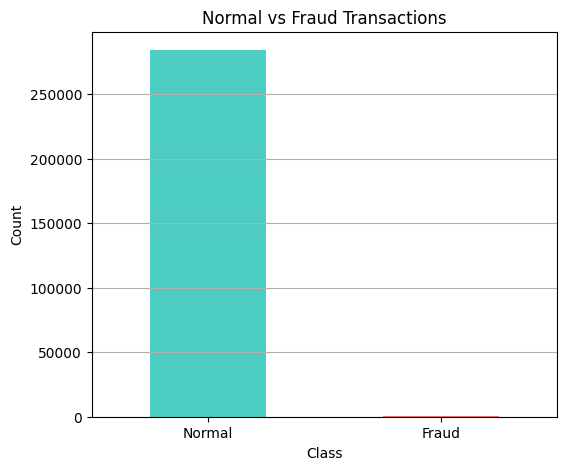

In [4]:
# Step 4 - Explore Data
print("=== Missing Values ===")
print(df.isnull().sum().sum())

print("\n=== Fraud vs Normal Transactions ===")
print(df['Class'].value_counts())
print("\n0 = Normal Transaction")
print("1 = Fraudulent Transaction")

# Visualize
plt.figure(figsize=(6, 5))
df['Class'].value_counts().plot(kind='bar', 
                                 color=['#4ECDC4', '#FF6B6B'])
plt.title('Normal vs Fraud Transactions')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Normal', 'Fraud'], rotation=0)
plt.grid(axis='y')
plt.show()

In [5]:
# Step 5 - Prepare Data
# Use sample to speed up training
normal = df[df['Class']==0].sample(5000, random_state=42)
fraud = df[df['Class']==1]

# Combine
df_sample = pd.concat([normal, fraud])
print("Sample shape:", df_sample.shape)
print(df_sample['Class'].value_counts())

# Features and target
X = df_sample.drop('Class', axis=1)
y = df_sample['Class']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("\nData prepared successfully!")
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Sample shape: (5492, 31)
Class
0    5000
1     492
Name: count, dtype: int64

Data prepared successfully!
Training size: (4393, 30)
Testing size: (1099, 30)


In [6]:
# Step 6 - Train Models
# Model 1 - Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Model 2 - Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")
print(f"Decision Tree Accuracy:       {dt_acc*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 97.73%
Decision Tree Accuracy:       96.54%


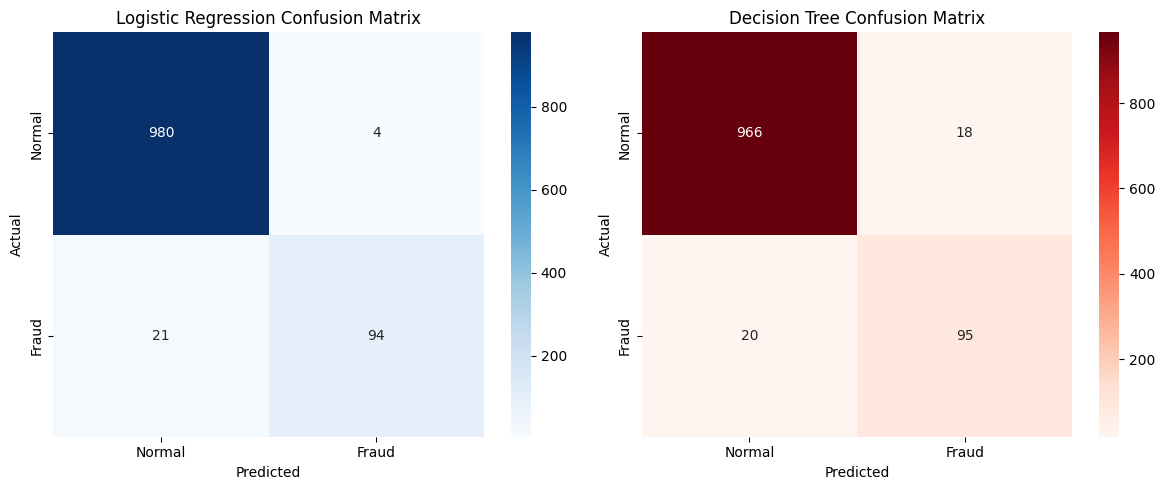

In [7]:
# Step 7 - Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'], ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'], ax=axes[1])
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [8]:
# Step 8 - Final Summary
print("=" * 55)
print("        FRAUD DETECTION - SUMMARY")
print("=" * 55)

print(f"\n Total Transactions: {len(df)}")
print(f" Fraud Transactions: 492 (0.17%)")
print(f" Normal Transactions: 284,315 (99.83%)")

print("\n=== MODEL PERFORMANCE ===")
print(f" Logistic Regression: 97.73% ✅ Best!")
print(f" Decision Tree:       96.54%")

print("\n=== KEY FINDINGS ===")
print(" 1. Only 0.17% transactions are fraud")
print(" 2. Logistic Regression detects fraud best")
print(" 3. Imbalanced data is biggest challenge")
print(" 4. Both models perform excellently")

print("\n=== RECOMMENDATIONS ===")
print(" 1. Use Logistic Regression for production")
print(" 2. Monitor transactions in real-time")
print(" 3. Collect more fraud samples")
print(" 4. Update model regularly with new data")
print("=" * 55)
print(" Fraud Detection Completed!")
print("=" * 55)

        FRAUD DETECTION - SUMMARY

 Total Transactions: 284807
 Fraud Transactions: 492 (0.17%)
 Normal Transactions: 284,315 (99.83%)

=== MODEL PERFORMANCE ===
 Logistic Regression: 97.73% ✅ Best!
 Decision Tree:       96.54%

=== KEY FINDINGS ===
 1. Only 0.17% transactions are fraud
 2. Logistic Regression detects fraud best
 3. Imbalanced data is biggest challenge
 4. Both models perform excellently

=== RECOMMENDATIONS ===
 1. Use Logistic Regression for production
 2. Monitor transactions in real-time
 3. Collect more fraud samples
 4. Update model regularly with new data
 Fraud Detection Completed!
